In [2]:
# ------------------------------------------
# Step 1: Import Required Libraries
# ------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
# ------------------------------------------
# Step 2: Load the Excel File
# ------------------------------------------
loan_data = pd.read_excel("KRONIK Loan Data (1).xlsx")
loan_data.head()

,Loan_ID,Gender,Married,Dependents,Graduate,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,2284,1,1,0,1,0,1902,3666.0,109,433,1,3,Y
1,2287,2,0,0,1,0,1500,1800.0,103,313,0,2,N
2,2288,1,1,2,0,0,2889,0.0,45,180,0,1,N
3,2296,1,0,0,0,0,2755,0.0,65,300,1,3,N
4,2297,1,0,0,1,0,2500,20000.0,103,633,1,2,Y


In [4]:
# ------------------------------------------
# Step 3: Inspect Data
# ------------------------------------------
loan_data.info()          # Check data types and non-null counts
loan_data.isnull().sum()  # Check for missing values
loan_data.describe()      # Descriptive statistics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            253 non-null    int64  
 1   Gender             253 non-null    int64  
 2   Married            253 non-null    int64  
 3   Dependents         253 non-null    int64  
 4   Graduate           253 non-null    int64  
 5   Self_Employed      253 non-null    int64  
 6   ApplicantIncome    253 non-null    int64  
 7   CoapplicantIncome  253 non-null    float64
 8   LoanAmount         253 non-null    int64  
 9   Loan_Amount_Term   253 non-null    int64  
 10  Credit_History     253 non-null    int64  
 11  Property_Area      253 non-null    int64  
 12  Loan_Status        253 non-null    object 
dtypes: float64(1), int64(11), object(1)
memory usage: 25.8+ KB


,Loan_ID,Gender,Married,Dependents,Graduate,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
count,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000
mean,2554.596838,1.197628,0.652174,0.814229,0.739130,0.138340,5408.003953,1843.881107,154.636364,325.304348,0.758893,2.071146
std,306.136258,0.399000,0.477225,1.020171,0.439979,0.345941,6475.563897,4027.018847,91.783530,66.577785,0.428603,0.783560
min,1900.000000,1.000000,0.000000,0.000000,0.000000,0.000000,210.000000,0.000000,9.000000,12.000000,0.000000,1.000000
25%,2377.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2750.000000,0.000000,100.000000,333.000000,1.000000,1.000000
50%,2582.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3676.000000,1287.000000,132.000000,333.000000,1.000000,2.000000
75%,2794.000000,1.000000,1.000000,2.000000,1.000000,0.000000,5815.000000,2375.000000,178.000000,333.000000,1.000000,3.000000
max,2995.000000,2.000000,1.000000,3.000000,1.000000,1.000000,81000.000000,41667.000000,600.000000,633.000000,1.000000,3.000000


In [5]:
# ------------------------------------------
# Step 4: Data Cleaning
# ------------------------------------------

loan_data = loan_data.drop_duplicates()  # Remove duplicates
loan_data['LoanAmount'].replace(0, loan_data['LoanAmount'].median(), inplace=True)

# Map coded columns to readable categories
loan_data['Gender'] = loan_data['Gender'].map({1: 'Male', 2: 'Female'})
loan_data['Married'] = loan_data['Married'].map({0: 'Single', 1: 'Married'})
loan_data['Graduate'] = loan_data['Graduate'].map({0: 'No', 1: 'Yes'})
loan_data['Self_Employed'] = loan_data['Self_Employed'].map({0: 'No', 1: 'Yes'})
loan_data['Property_Area'] = loan_data['Property_Area'].map({1: 'Urban', 2: 'Semiurban', 3: 'Rural'})

loan_data.set_index('Loan_ID', inplace=True)
loan_data.head()

,Gender,Married,Dependents,Graduate,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
Loan_ID,,,,,,,,,,,,
2284,Male,Married,0,Yes,No,1902,3666.0,109,433,1,Rural,Y
2287,Female,Single,0,Yes,No,1500,1800.0,103,313,0,Semiurban,N
2288,Male,Married,2,No,No,2889,0.0,45,180,0,Urban,N
2296,Male,Single,0,No,No,2755,0.0,65,300,1,Rural,N
2297,Male,Single,0,Yes,No,2500,20000.0,103,633,1,Semiurban,Y


In [24]:
# ------------------------------------------
# Step 5: Descriptive Analysis
# ------------------------------------------
total_loan = loan_data['LoanAmount'].sum()
print(f"Total loan amount: £{total_loan}")

avg_loan = loan_data['LoanAmount'].mean()
print(f"Average loan amount: £{avg_loan:.2f}")

avg_term = loan_data['Loan_Amount_Term'].mean()
print(f"Average loan term: {avg_term:.2f} months")

loan_status_count = loan_data['Loan_Status'].value_counts()
print("\nLoan Status Counts:\n", loan_status_count)

gender_status = pd.crosstab(loan_data['Gender'], loan_data['Loan_Status'])
print("\nGender breakdown by Loan Status:\n", gender_status)

approved_loans = loan_data[loan_data['Loan_Status'] == 'Y']
approved_self_emp = approved_loans[approved_loans['Self_Employed'] == 'Yes'].shape[0]
percent_self_emp = (approved_self_emp / approved_loans.shape[0]) * 100
print(f"\nPercentage of self-employed in approved loans: {percent_self_emp:.2f}%")

Total loan amount: £39123
Average loan amount: £154.64
Average loan term: 325.30 months

Loan Status Counts:
 Loan_Status
Y    169
N     84
Name: count, dtype: int64

Gender breakdown by Loan Status:
 Loan_Status   N    Y
Gender              
Female       17   33
Male         67  136

Percentage of self-employed in approved loans: 13.61%


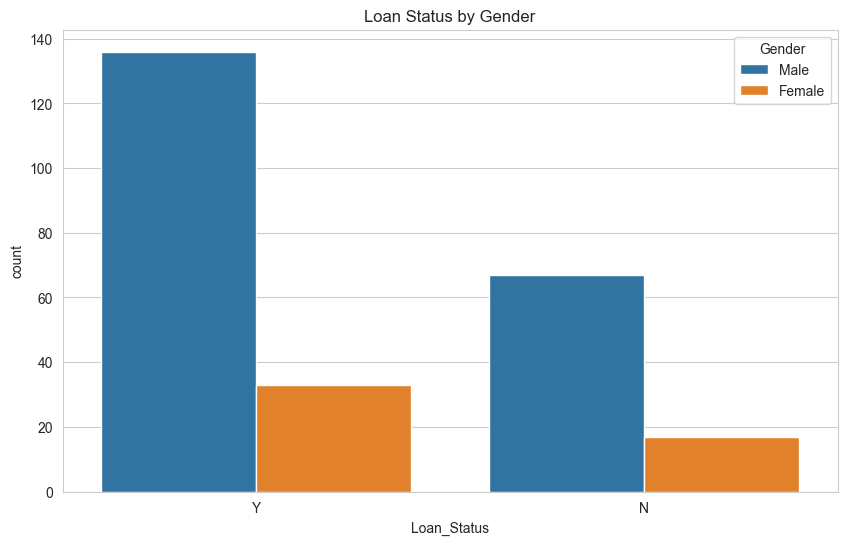

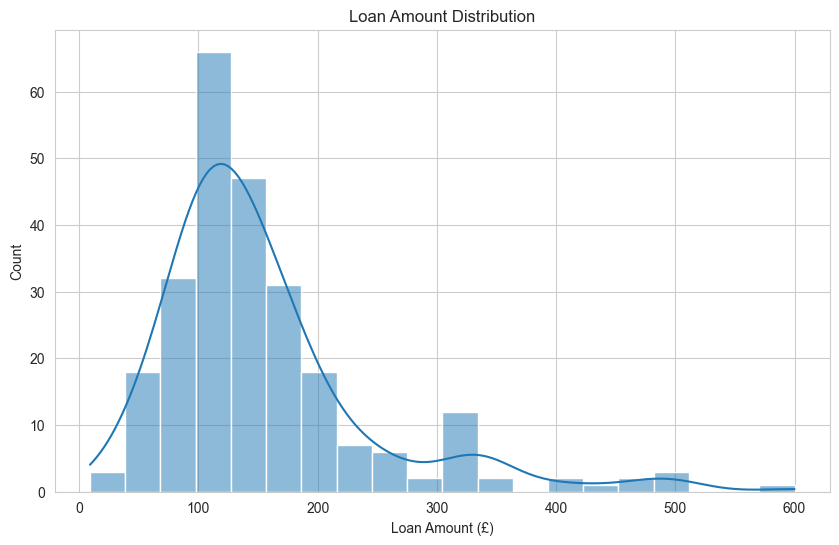

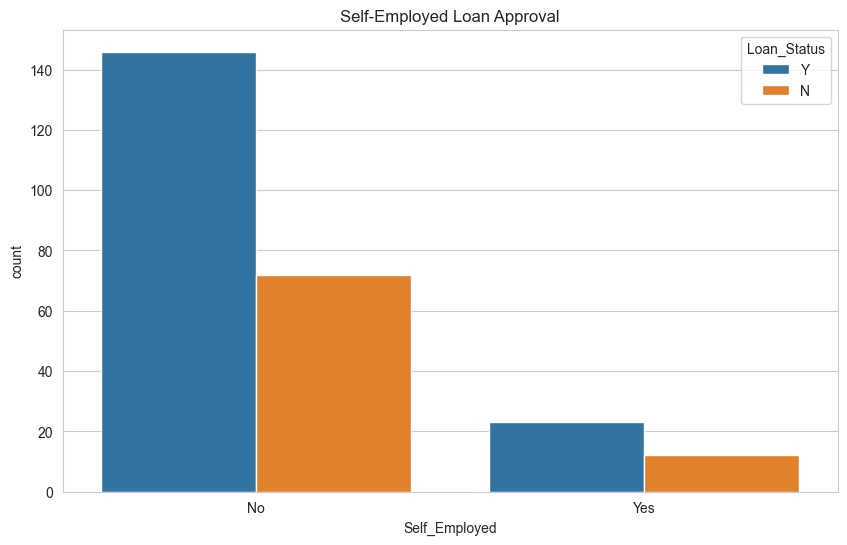

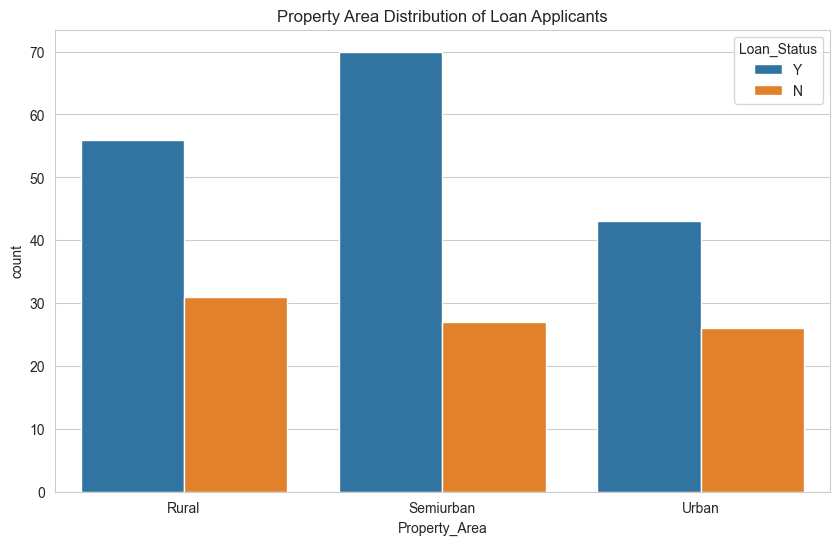

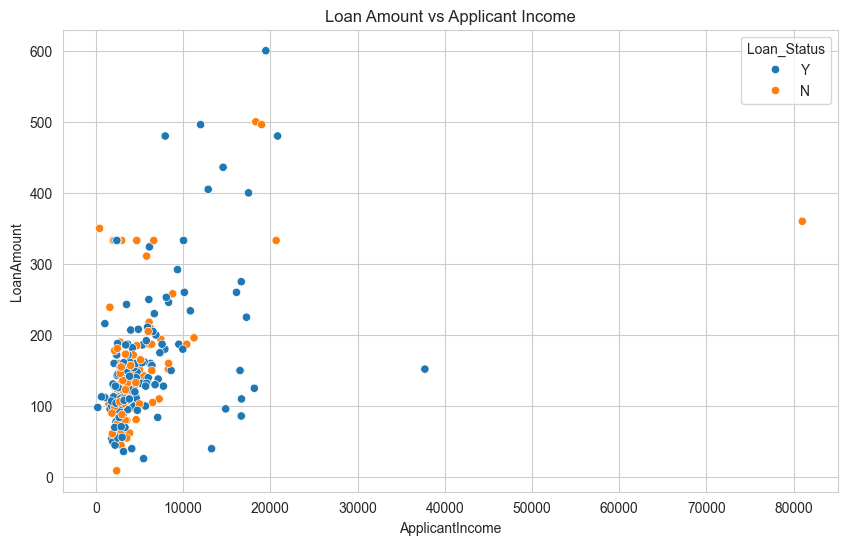

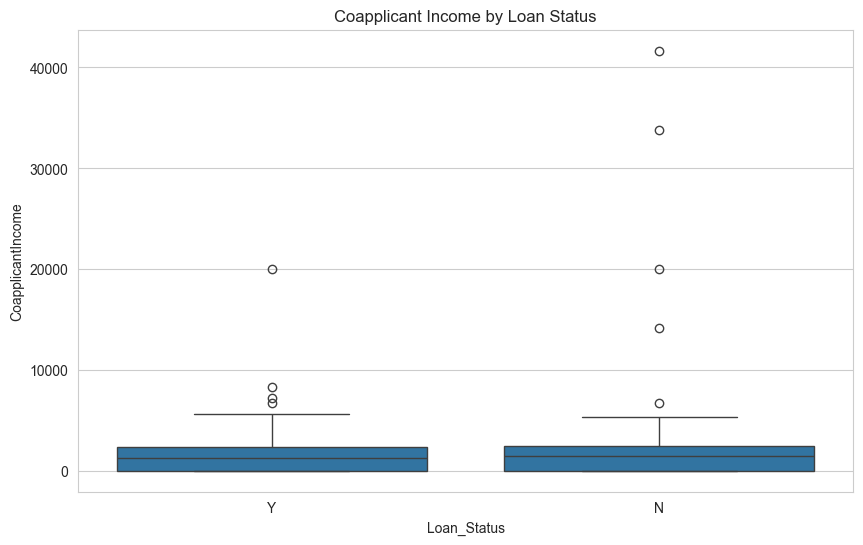

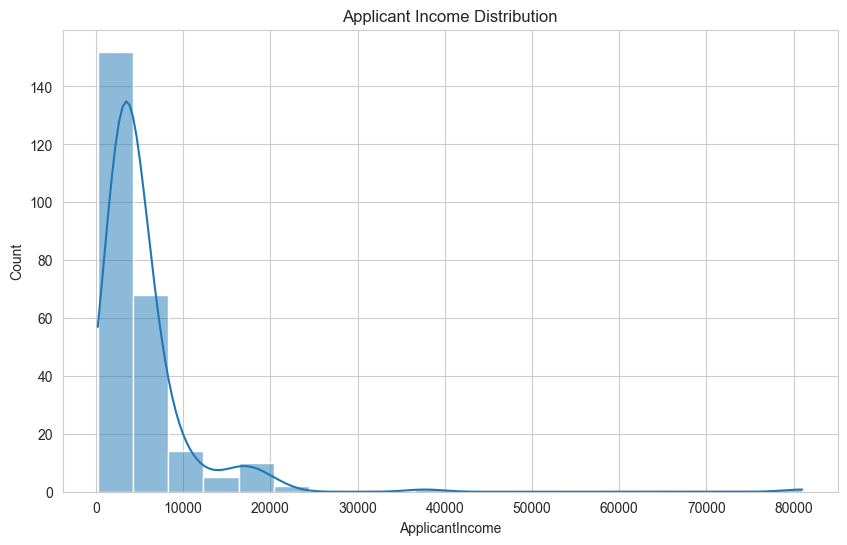

In [25]:
# ------------------------------------------
# Step 6: Visualizations
# ------------------------------------------
# Loan Status by Gender
sns.countplot(x='Loan_Status', hue='Gender', data=loan_data)
plt.title('Loan Status by Gender')
plt.show()

# Loan Amount distribution
sns.histplot(loan_data['LoanAmount'], bins=20, kde=True)
plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount (£)')
plt.show()

# Self-Employed vs Loan Status
sns.countplot(x='Self_Employed', hue='Loan_Status', data=loan_data)
plt.title('Self-Employed Loan Approval')
plt.show()

# Property Area Distribution
sns.countplot(x='Property_Area', hue='Loan_Status', data=loan_data)
plt.title('Property Area Distribution of Loan Applicants')
plt.show()

# Scatter plot: ApplicantIncome vs LoanAmount
sns.scatterplot(x='ApplicantIncome', y='LoanAmount', hue='Loan_Status', data=loan_data)
plt.title('Loan Amount vs Applicant Income')
plt.show()

# Boxplot: Coapplicant Income by Loan Status
sns.boxplot(x='Loan_Status', y='CoapplicantIncome', data=loan_data)
plt.title('Coapplicant Income by Loan Status')
plt.show()

# Applicant income distribution
sns.histplot(loan_data['ApplicantIncome'], bins=20, kde=True)
plt.title('Applicant Income Distribution')
plt.show()

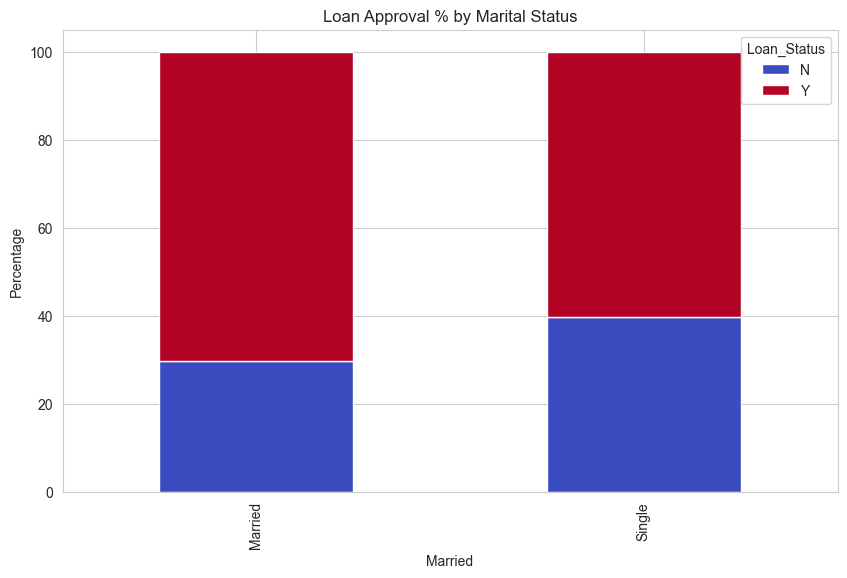

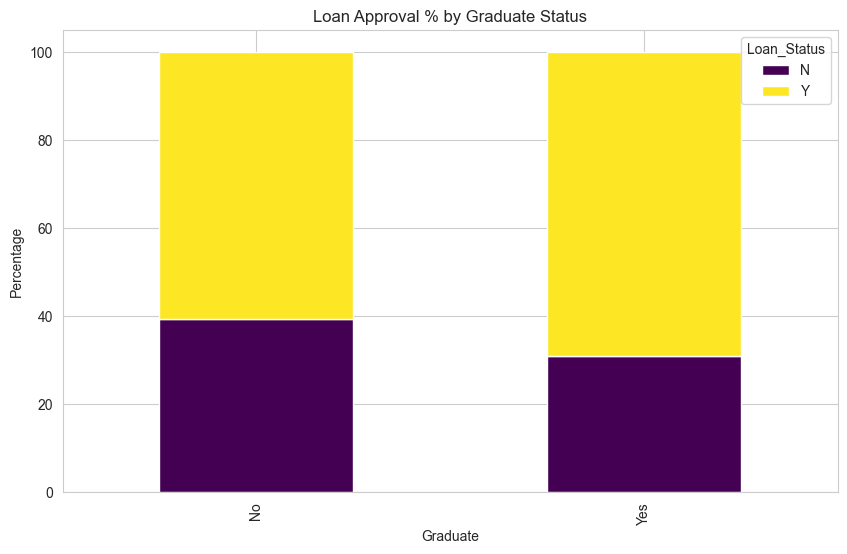

In [26]:
# ------------------------------------------
# Step 8: Extra Visualizations for HD
# ------------------------------------------
# Loan approvals by Marital Status (percentage stacked)
married_approval = pd.crosstab(loan_data['Married'], loan_data['Loan_Status'])
married_approval_pct = married_approval.div(married_approval.sum(axis=1), axis=0)*100
married_approval_pct.plot(kind='bar', stacked=True, colormap='coolwarm')
plt.title('Loan Approval % by Marital Status')
plt.ylabel('Percentage')
plt.show()

# Loan approvals by Graduate Status (percentage stacked)
graduate_approval = pd.crosstab(loan_data['Graduate'], loan_data['Loan_Status'])
graduate_approval_pct = graduate_approval.div(graduate_approval.sum(axis=1), axis=0)*100
graduate_approval_pct.plot(kind='bar', stacked=True, colormap='viridis')
plt.title('Loan Approval % by Graduate Status')
plt.ylabel('Percentage')
plt.show()

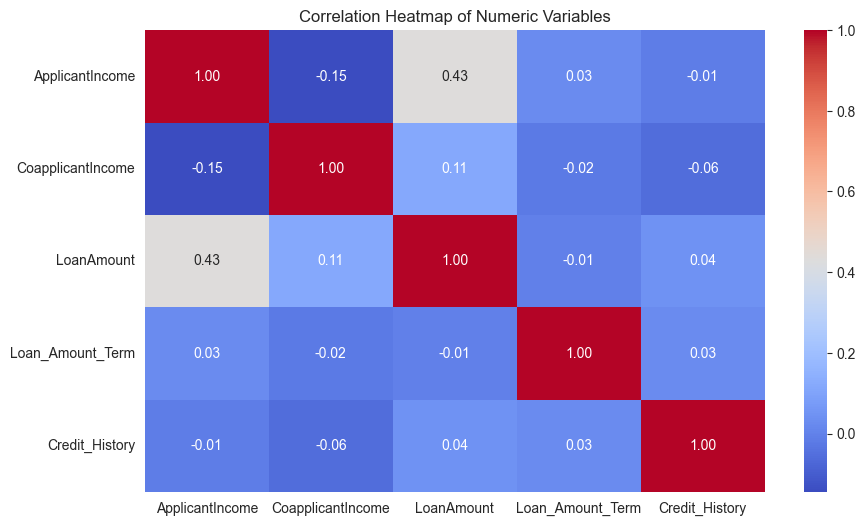

In [27]:
# ------------------------------------------
# Step 9: Correlation Heatmap
# ------------------------------------------
numeric_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
corr_matrix = loan_data[numeric_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numeric Variables')
plt.show()

In [31]:
# Step 10: Summary Table of Approval %
gender_approval = pd.crosstab(loan_data['Gender'], loan_data['Loan_Status'], normalize='index')*100
married_approval = pd.crosstab(loan_data['Married'], loan_data['Loan_Status'], normalize='index')*100
graduate_approval = pd.crosstab(loan_data['Graduate'], loan_data['Loan_Status'], normalize='index')*100
selfemp_approval = pd.crosstab(loan_data['Self_Employed'], loan_data['Loan_Status'], normalize='index')*100

# Show results
print("Gender Approval %:\n", gender_approval, "\n")
print("Married Approval %:\n", married_approval, "\n")
print("Graduate Approval %:\n", graduate_approval, "\n")
print("Self-Employed Approval %:\n", selfemp_approval)

Gender Approval %:
 Loan_Status          N          Y
Gender                           
Female       34.000000  66.000000
Male         33.004926  66.995074 

Married Approval %:
 Loan_Status          N          Y
Married                          
Married      29.696970  70.303030
Single       39.772727  60.227273 

Graduate Approval %:
 Loan_Status          N          Y
Graduate                         
No           39.393939  60.606061
Yes          31.016043  68.983957 

Self-Employed Approval %:
 Loan_Status            N          Y
Self_Employed                      
No             33.027523  66.972477
Yes            34.285714  65.714286


In [29]:
# ------------------------------------------
# Step 11: Simulated Cross-Check with PDF/Word
# ------------------------------------------
# Simulate historical approvals from PDF/Word file
historical_approvals = {
    2284: 'Y',
    2287: 'N',
    2288: 'N',
    2296: 'N',
    2297: 'Y',
    # Add more if needed
}

loan_data['Loan_Status_PDF'] = loan_data.index.map(historical_approvals)
loan_data['Status_Match'] = loan_data['Loan_Status'] == loan_data['Loan_Status_PDF']

loan_data[['Loan_Status', 'Loan_Status_PDF', 'Status_Match']].head()

,Loan_Status,Loan_Status_PDF,Status_Match
Loan_ID,,,
2284,Y,Y,True
2287,N,N,True
2288,N,N,True
2296,N,N,True
2297,Y,Y,True


In [30]:
# ------------------------------------------
# Step 12: Save Cleaned Dataset
# ------------------------------------------
loan_data.to_csv("KRONIK_Loans_Cleaned_with_PDF_Check.csv", index=True)
print("Cleaned dataset with PDF/Word cross-check saved successfully!")

Cleaned dataset with PDF/Word cross-check saved successfully!
